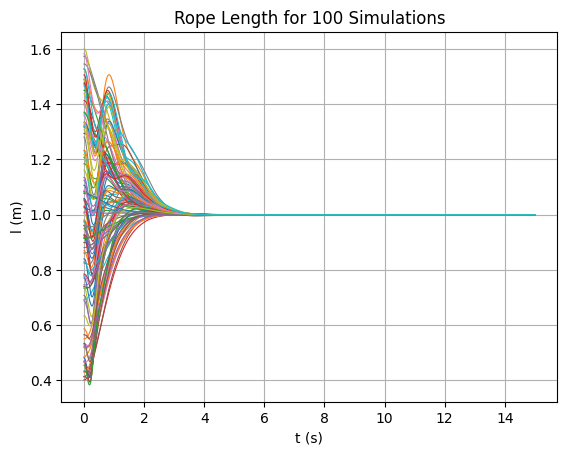

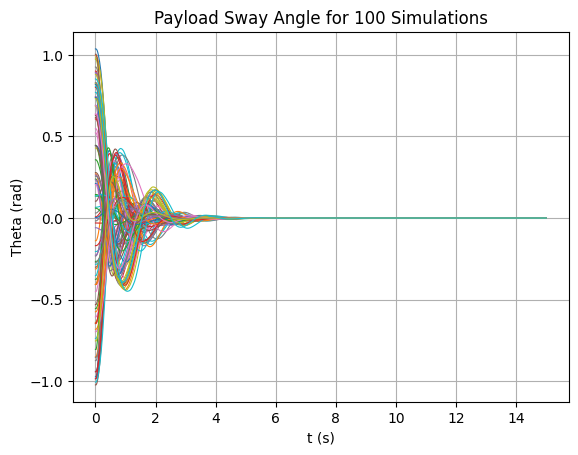

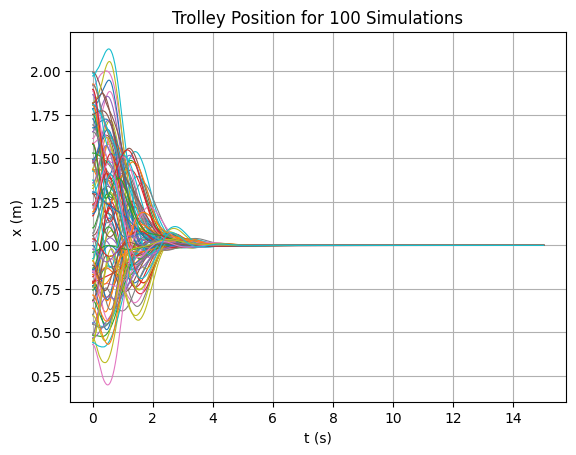

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(1)
plt.grid(True)
plt.xlabel("t (s)")
plt.ylabel("x (m)")
plt.title("Trolley Position for 100 Simulations")

plt.figure(2)
plt.grid(True)
plt.xlabel("t (s)")
plt.ylabel("l (m)")
plt.title("Rope Length for 100 Simulations")

plt.figure(3)
plt.grid(True)
plt.xlabel("t (s)")
plt.ylabel("Theta (rad)")
plt.title("Payload Sway Angle for 100 Simulations")

for i in range(1, 101):
    file = f"Simulation_{i:03d}.xlsx"
    obs = pd.read_excel(file, sheet_name="Observation")

    t = obs["Time"]
    x = obs["ex"] + 1
    l = obs["el"] + 1
    theta = obs["Theta"]

    plt.figure(1)
    plt.plot(t, x, linewidth=0.8)

    plt.figure(2)
    plt.plot(t, l, linewidth=0.8)

    plt.figure(3)
    plt.plot(t, theta, linewidth=0.8)

plt.figure(1)
plt.show()

plt.figure(2)
plt.show()

plt.figure(3)
plt.show()

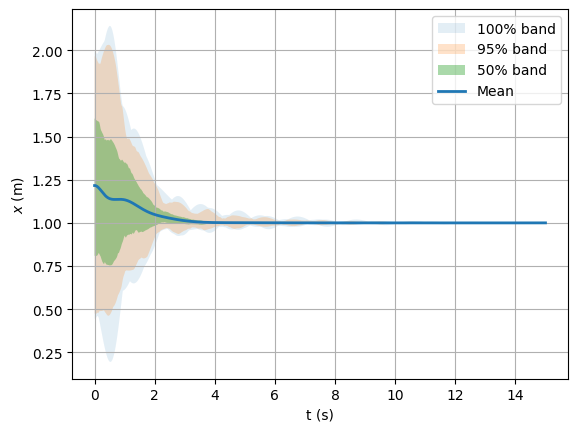

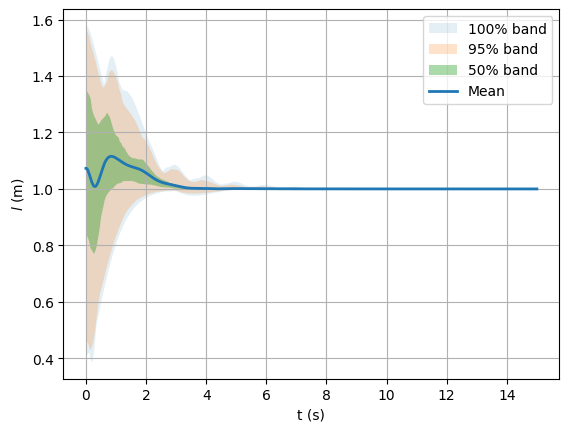

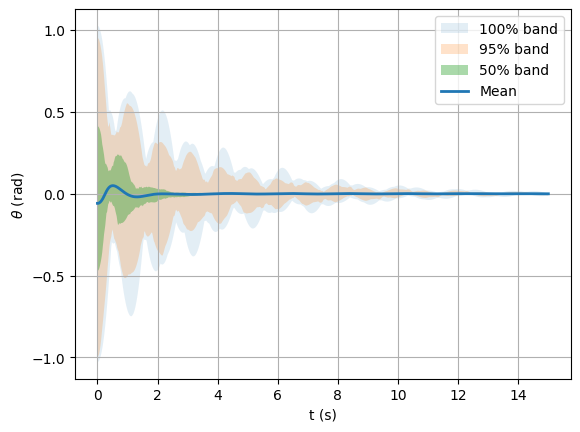

: 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

numSim = 100

all_x = []
all_l = []
all_theta = []

for i in range(1, numSim + 1):
    file = f"Simulation_{i:03d}.xlsx"
    obs = pd.read_excel(file, sheet_name="Observation")

    t = obs["Time"].values
    all_x.append((obs["ex"] + 1).values)
    all_l.append((obs["el"] + 1).values)
    all_theta.append(obs["Theta"].values)

all_x = np.array(all_x)
all_l = np.array(all_l)
all_theta = np.array(all_theta)

def plot_confidence_band(t, data, ylabel, title):
    mean = np.mean(data, axis=0)

    p0 = np.min(data, axis=0)
    p2_5 = np.percentile(data, 2.5, axis=0)
    p25 = np.percentile(data, 25, axis=0)
    p75 = np.percentile(data, 75, axis=0)
    p97_5 = np.percentile(data, 97.5, axis=0)
    p100 = np.max(data, axis=0)

    plt.figure()
    plt.fill_between(t, p0, p100, alpha=0.12, label="100% band")
    plt.fill_between(t, p2_5, p97_5, alpha=0.22, label="95% band")
    plt.fill_between(t, p25, p75, alpha=0.40, label="50% band")
    plt.plot(t, mean, linewidth=2, label="Mean")

    plt.grid(True)
    plt.xlabel("t (s)")
    plt.ylabel(ylabel)
    #plt.title(title)
    plt.legend()
    plt.show()

plot_confidence_band(t, all_x, "$x$ (m)", "Trolley Position: 100 Simulations")
plot_confidence_band(t, all_l, "$l$ (m)", "Rope Length: 100 Simulations")
plot_confidence_band(t, all_theta, "$\\theta$ (rad)", "Payload Sway Angle: 100 Simulations")